# Outline

This notebook is used to conduct data analysis step by step before entering preprocessing and prediction. This will help me decide what preprocess I need to do.

Notebook Outline

* Load Data And Library
* Check Data Basic Information
* Data Visualization
* Correlation Map

# Load Data And Library

In [1]:
# import necessary library
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [2]:
# config
class CFG:
    train_csv = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
    test_csv = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
    sample_submission_csv = '/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv'
    N_FOLDS = 5
    RANDOM_SEED = 42
    
#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
train = pd.read_csv(CFG.train_csv)
test = pd.read_csv(CFG.test_csv)

# Check Data Basic Information

In [4]:
#check what is in the data
print("------------train data------------")
display(train.head())
print(train.describe())
print("------------test data------------")
display(test.head())
print(test.describe())

------------train data------------


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


                  id        Soil_pH  Soil_Moisture  Organic_Carbon  \
count  630000.000000  630000.000000  630000.000000   630000.000000   
mean   314999.500000       6.482497      37.304482        0.922858   
std    181865.479132       0.922504      16.377082        0.365808   
min         0.000000       4.800000       8.000000        0.300000   
25%    157499.750000       5.690000      23.340000        0.610000   
50%    314999.500000       6.440000      37.750000        0.910000   
75%    472499.250000       7.270000      51.270000        1.220000   
max    629999.000000       8.200000      64.990000        1.600000   

       Electrical_Conductivity  Temperature_C       Humidity    Rainfall_mm  \
count            630000.000000  630000.000000  630000.000000  630000.000000   
mean                  1.744605      26.998166      61.563180    1462.207566   
std                   0.952321       8.623621      19.708152     612.989738   
min                   0.100000      12.000000      25

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


                  id        Soil_pH  Soil_Moisture  Organic_Carbon  \
count  270000.000000  270000.000000  270000.000000   270000.000000   
mean   764999.500000       6.480929      37.307614        0.922279   
std     77942.430678       0.922187      16.375273        0.365757   
min    630000.000000       4.800000       8.010000        0.300000   
25%    697499.750000       5.680000      23.340000        0.610000   
50%    764999.500000       6.440000      37.770000        0.900000   
75%    832499.250000       7.260000      51.200000        1.220000   
max    899999.000000       8.200000      64.990000        1.600000   

       Electrical_Conductivity  Temperature_C       Humidity    Rainfall_mm  \
count            270000.000000  270000.000000  270000.000000  270000.000000   
mean                  1.745251      27.001666      61.511319    1464.525885   
std                   0.951329       8.630706      19.690278     612.521709   
min                   0.100000      12.010000      25

In [5]:
# check if there is miss data in training data or testing data
print(train.isnull().sum())
print(test.isnull().sum())

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
S

# Data Visualization

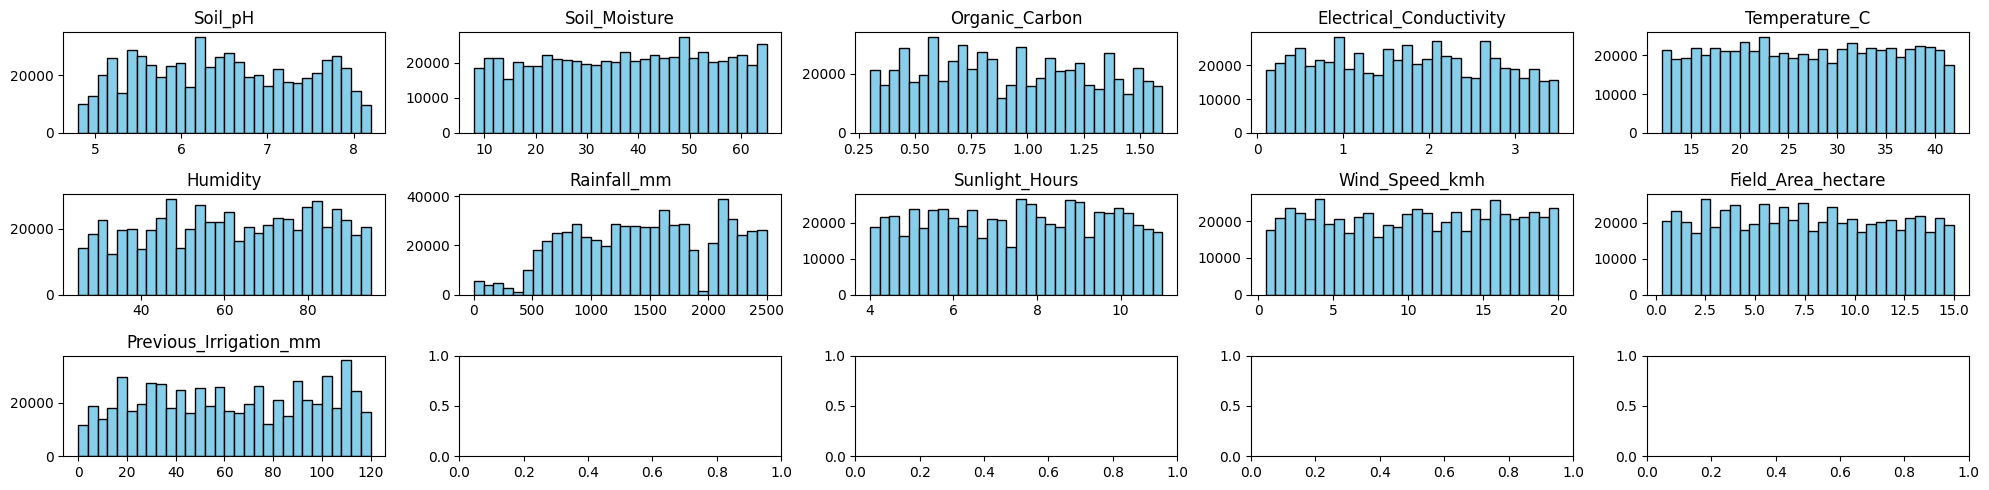

In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id']]
total_col = len(numeric_cols)
subplot_x = int(total_col / 5) + 1
subplot_y = 5

fig, axs = plt.subplots(subplot_x, subplot_y, figsize=(20, 5)) # Adjust grid size as needed
axs = axs.flatten() # Flattens the 2D grid to 1D

for i, col in enumerate(numeric_cols):
    if i < len(axs):
        axs[i].hist(train[col], bins=30, color='skyblue', edgecolor='black')
        axs[i].set_title(col)
    else:
        axs[i].axis('off') # Hide unused subplots

plt.tight_layout()
plt.show()

In [7]:
non_numeric_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()
for col in non_numeric_cols:
    print(col," : ",train[col].unique())

Soil_Type  :  ['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type  :  ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage  :  ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season  :  ['Zaid' 'Kharif' 'Rabi']
Irrigation_Type  :  ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source  :  ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used  :  ['No' 'Yes']
Region  :  ['East' 'South' 'North' 'West' 'Central']
Irrigation_Need  :  ['Low' 'Medium' 'High']


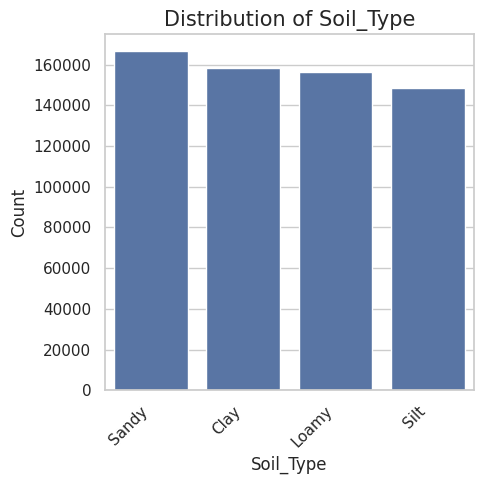

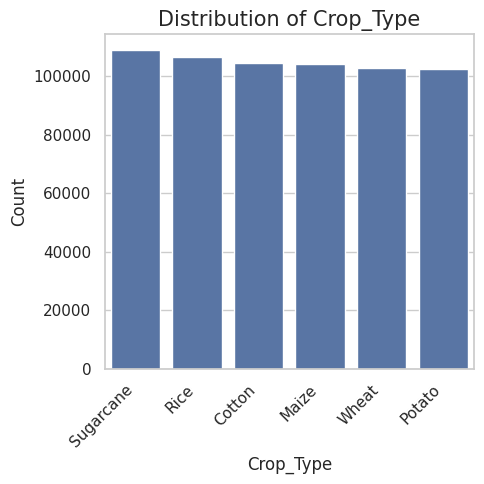

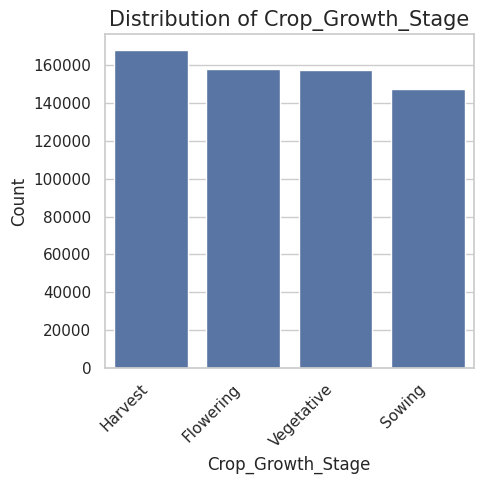

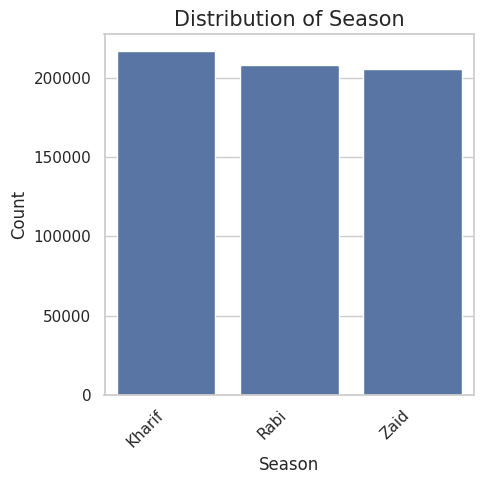

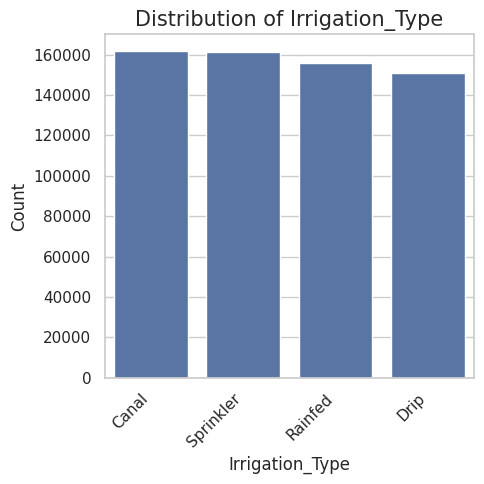

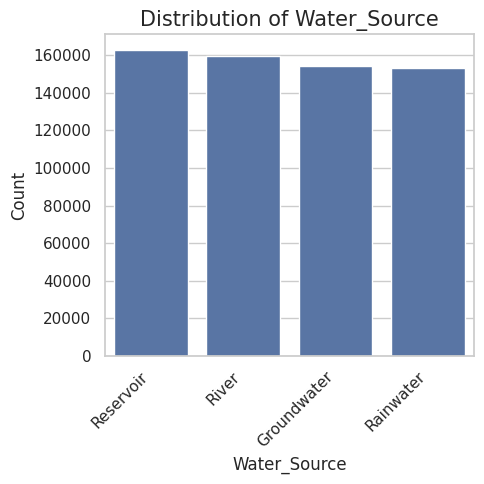

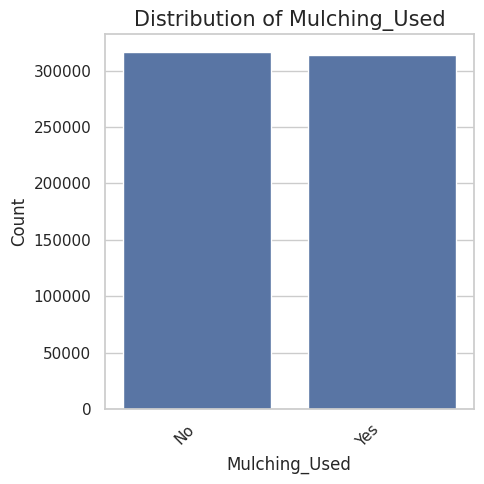

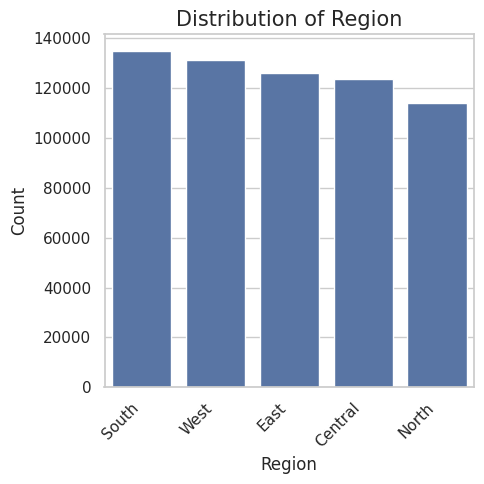

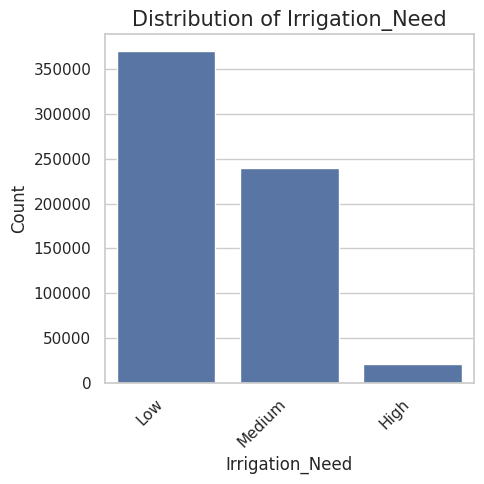

In [8]:
sns.set(style="whitegrid")
#PLOT NON NUMERIC DATA
for col in non_numeric_cols:
    # (width, height)
    plt.figure(figsize=(5, 5))
    
    # order plot with most number to least number data
    sns.countplot(data=train, x=col, order=train[col].value_counts().index)
    
    # title and x label
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # rotate to avoid x axis on top of each other
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

**Key note: All non-numerical feature need to be preprocessed with following rules.**

1. Mapping: Mulching_Used(Yes, No >> 1, 0), Irrigation_Need(Low, Medium, High >> 0, 1, 2), Crop_Growth_Stage(Sowing': 0, 'Vegetative': 1, 'Flowering': 2, 'Harvest': 3)
2. Region, Water_Source, Irrigation_Type, Season, Crop_Type, Soil_Type use One-Hot Encoding

# Correlation Map

In [9]:
train_raw = train.drop(columns=['id'])
train_raw.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [10]:
one_hot_encoded_train_raw = pd.get_dummies(train_raw)

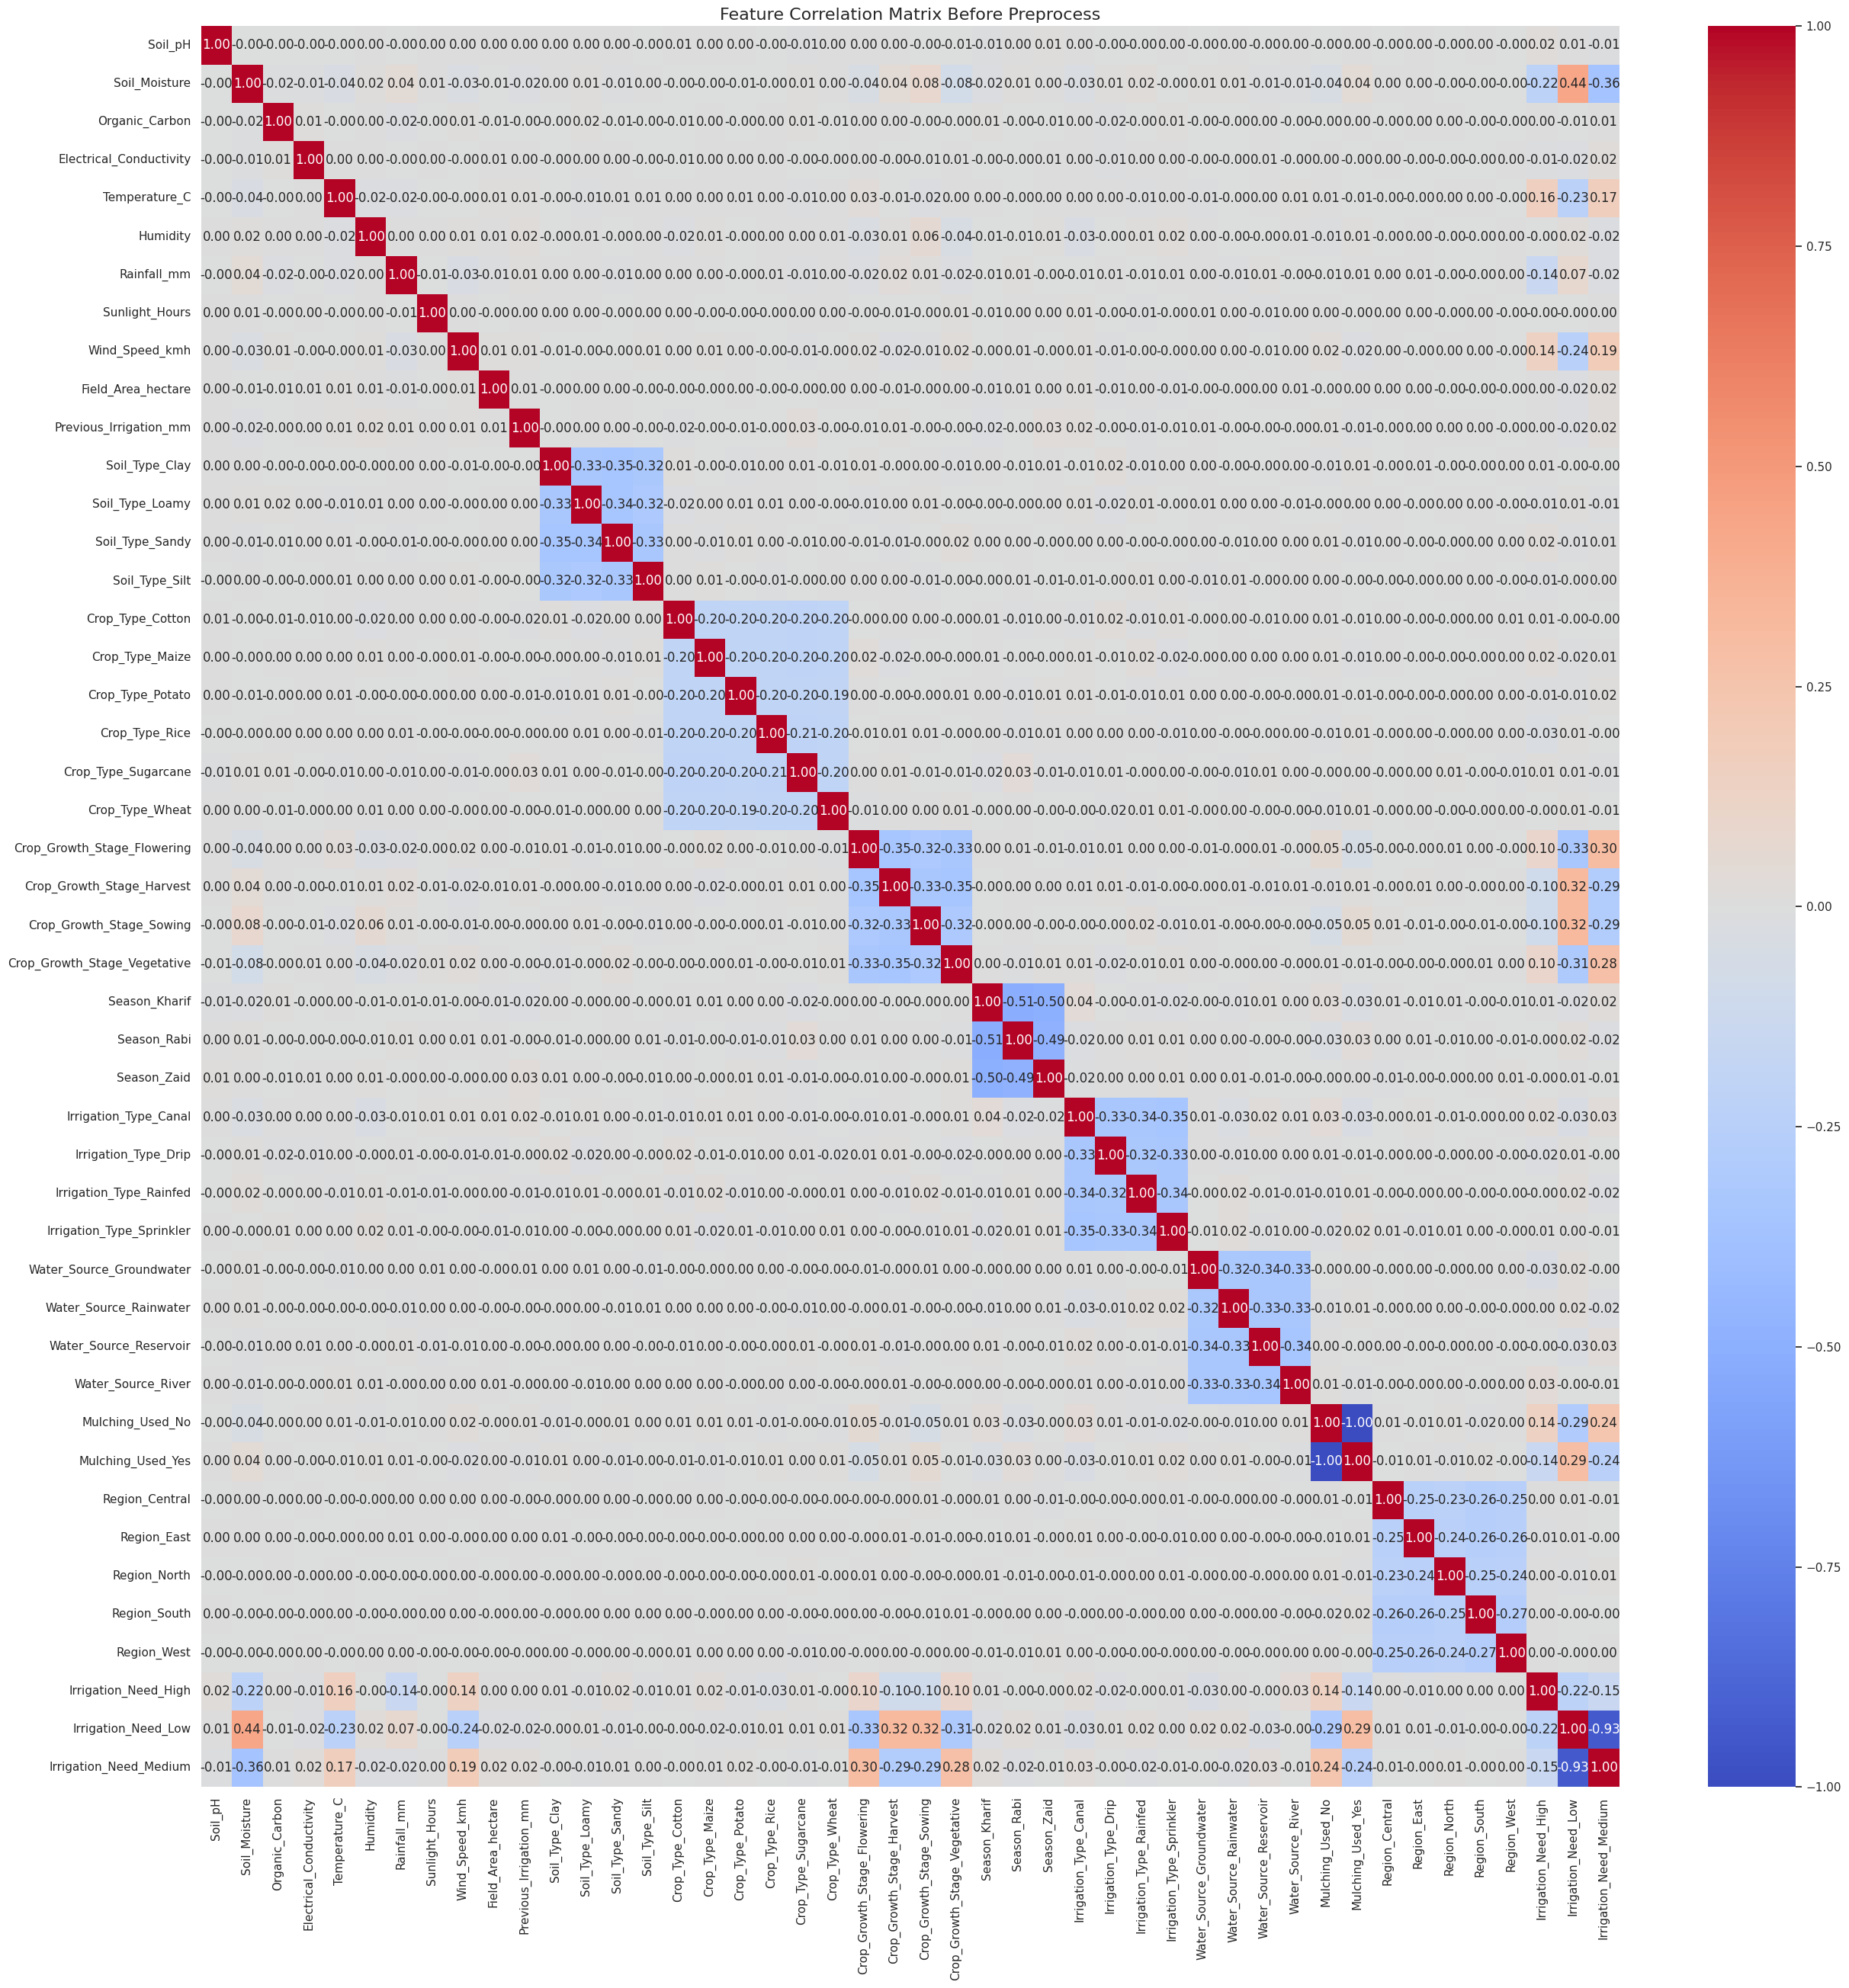

In [11]:
# Check the correlation map before preprocess
# Then compare it with the correlation map of after preprocess 
corr_matrix = one_hot_encoded_train_raw.corr()

# Setup the figure size (make it large enough to read)
plt.figure(figsize=(30, 30))

# Create the Heatmap
# annot=True: shows the numbers
# cmap='coolwarm': Blue for negative corr, Red for positive
# fmt=".2f": limits decimals to 2 places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Matrix Before Preprocess", fontsize=16)
plt.show()

# Conclusion

Categorize Features: Identify Ordinal (Growth Stage), Nominal (Soil Type, Region), and Binary (Mulching) types.

Ordinal Encoding: Map ranked categories (e.g., Sowing=0, Harvest=3) to preserve their sequence.

One-Hot Encoding: Use for nominal features with low cardinality like Season.

Fix Multicollinearity: Drop one column from binary pairs (e.g., drop Mulching_No) to remove redundancy.

Target Encoding: Use for Crop_Type with cross-validation to avoid leakage.

Prevent Leakage: Ensure Irrigation_Need columns are not accidentally used as predictors.

Feature Engineering: Create interaction terms like Temperature × Sunlight_Hours.

Scaling: Normalize numerical values like Soil_Moisture if using distance-based models.